# Evaluacion Parcial N2 - 10 - Analisis Final

## Objetivo del Análisis Final

En este notebook se realiza la etapa final del proyecto, utilizando el modelo de regresión optimizado para estimar el precio justo de modelos LLM según el valor entregado.

A partir de las predicciones generadas, se busca identificar:

- Modelos subvalorados.
- Modelos sobrevalorados.
- Modelos correctamente valuados.

El análisis permitirá responder la pregunta central del proyecto:

### ¿Es justo el precio de los modelos LLM?

Para ello se comparará el precio real de mercado con el precio estimado por el modelo de Machine Learning entrenado en notebooks anteriores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup completo')

Setup completo


## Preparación de Datos y Carga del Modelo Optimizado

Se reutiliza el pipeline de limpieza y transformación desarrollado anteriormente para asegurar consistencia metodológica.

Posteriormente se carga el modelo Random Forest optimizado, el cual fue seleccionado debido a su mayor estabilidad y capacidad de generalización durante la validación cruzada y optimización de hiperparámetros.

### Metodología Utilizada

El análisis final se basa en comparar:

- Precio real de mercado.
- Precio predicho por el modelo.

La diferencia entre ambos valores permitirá estimar si un modelo está:

- subvalorado,
- sobrevalorado,
- o correctamente valorizado.

Esta metodología es similar a enfoques utilizados en:
- valuación financiera,
- pricing dinámico,
- detección de anomalías,
- modelos de recomendación económica.

In [2]:
df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')
df['input_cost_usd_per_1m'] = df['input_cost_usd_per_1m'] / 100
df['output_cost_usd_per_1m'] = df['output_cost_usd_per_1m'] / 100

df_limpio = df.dropna(subset=['aa_intelligence_index', 'aa_coding_index'], how='all').copy()

df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'] = df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'].fillna(0)
df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'] = df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'].fillna(0)

columnas = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index', 'input_cost_usd_per_1m', 'output_cost_usd_per_1m', 'output_tokens_per_second', 'time_to_first_token_s', 'chatbot_arena_elo', 'release_year']
for col in columnas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio.groupby('provider')[col].transform(lambda x: x.fillna(x.median()))
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

df_limpio['costo_promedio'] = (df_limpio['input_cost_usd_per_1m'] + df_limpio['output_cost_usd_per_1m']) / 2

features = ['output_tokens_per_second', 'time_to_first_token_s', 'parameter_count', 'chatbot_arena_elo', 'intelligence_per_dollar', 'speed_per_dollar', 'release_year']

for col in features:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

X = df_limpio[features].dropna()
y = df_limpio.loc[X.index, 'costo_promedio']

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

with open('../models/trained_models/rf_regression_optimizado.pkl', 'rb') as f:
    rf_optimizado = pickle.load(f)

df_analisis = df_limpio.loc[X.index].copy()
df_analisis['precio_predicho_justo'] = rf_optimizado.predict(X_escalado)
df_analisis['desviacion'] = df_analisis['costo_promedio'] - df_analisis['precio_predicho_justo']

print(f'Datos analizados: {len(df_analisis)} modelos')

Datos analizados: 448 modelos


## Clasificación de Modelos Según Equidad de Precio

Para interpretar los resultados del modelo se calcula la desviación entre:

- precio real,
- precio justo predicho.

### Fórmula Utilizada

\[
Desviación = Precio\ Real - Precio\ Predicho
\]

Interpretación:

- Desviación negativa → modelo subvalorado.
- Desviación positiva → modelo sobrevalorado.
- Desviación cercana a cero → precio coherente con el valor entregado.

Se define un rango de tolerancia de ±0.002 USD para considerar modelos justamente valuados, evitando clasificaciones extremas por pequeñas variaciones estadísticas.

In [3]:
subvaluados = df_analisis[df_analisis['desviacion'] < -0.002]
sobrevalorados = df_analisis[df_analisis['desviacion'] > 0.002]
justamente_valuados = df_analisis[(df_analisis['desviacion'] >= -0.002) & (df_analisis['desviacion'] <= 0.002)]

print('EQUIDAD DE PRECIOS')
print(f'Subvaluados: {len(subvaluados)} ({len(subvaluados)/len(df_analisis)*100:.1f}%)')
print(f'Justamente valuados: {len(justamente_valuados)} ({len(justamente_valuados)/len(df_analisis)*100:.1f}%)')
print(f'Sobrevalorados: {len(sobrevalorados)} ({len(sobrevalorados)/len(df_analisis)*100:.1f}%)')

EQUIDAD DE PRECIOS
Subvaluados: 76 (17.0%)
Justamente valuados: 289 (64.5%)
Sobrevalorados: 83 (18.5%)


### Interpretación de Resultados

La distribución obtenida permite analizar cómo se comporta el mercado de modelos LLM respecto al valor realmente entregado.

- Una alta cantidad de modelos justamente valuados sugiere que el mercado posee cierta eficiencia.
- Modelos subvalorados representan oportunidades competitivas.
- Modelos sobrevalorados podrían depender más de reputación de marca o posicionamiento estratégico.

Este análisis permite transformar el modelo predictivo en una herramienta de evaluación económica del mercado de inteligencia artificial.

## Distribución de Desviaciones de Precio

El siguiente gráfico muestra cómo se distribuyen las diferencias entre el precio real y el precio justo estimado por el modelo.

### ¿Qué representa este gráfico?

- Valores cercanos a cero indican precios coherentes.
- Valores negativos indican modelos más baratos de lo esperado.
- Valores positivos indican modelos más caros de lo esperado.

### ¿Por qué usar un histograma?

El histograma permite observar:

- concentración de modelos,
- dispersión de precios,
- existencia de sesgos,
- presencia de outliers económicos.

Esto facilita entender si el mercado presenta comportamientos relativamente equilibrados o distorsiones importantes de pricing.

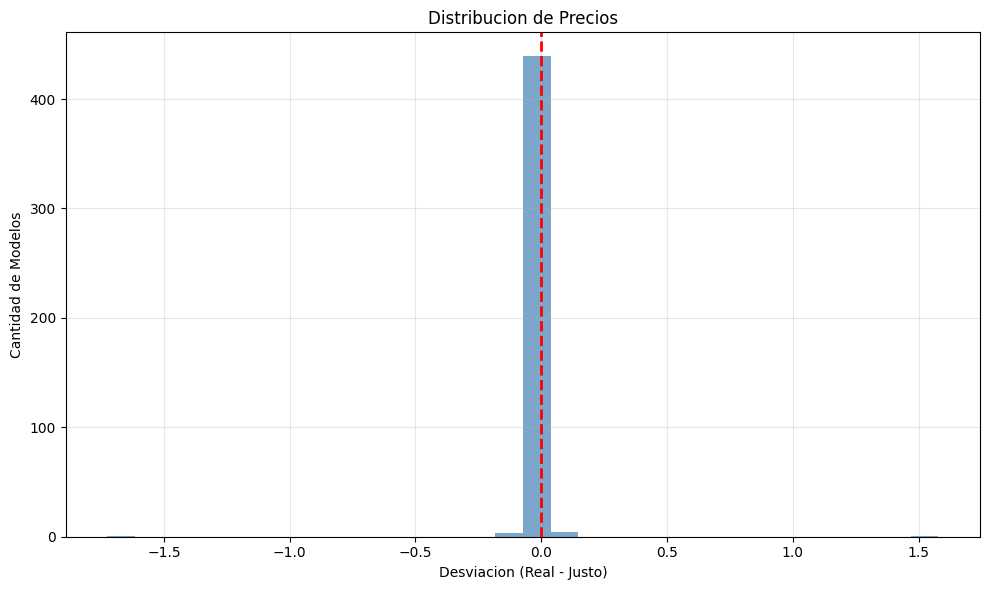

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_analisis['desviacion'], bins=30, color='steelblue', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Desviacion (Real - Justo)')
ax.set_ylabel('Cantidad de Modelos')
ax.set_title('Distribucion de Precios')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/plots/10_distribucion.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación del Histograma

La línea roja central representa el punto de equilibrio entre precio real y precio estimado.

Si la mayor parte de los modelos se concentra cerca de esta línea, significa que el mercado sigue patrones relativamente coherentes de pricing.

En cambio:

- colas largas hacia valores positivos reflejan posibles modelos premium sobrevalorados,
- colas negativas reflejan modelos con alta relación costo-beneficio.

La dispersión observada confirma que el pricing en modelos LLM no depende únicamente de inteligencia técnica, sino también de factores comerciales y estratégicos.

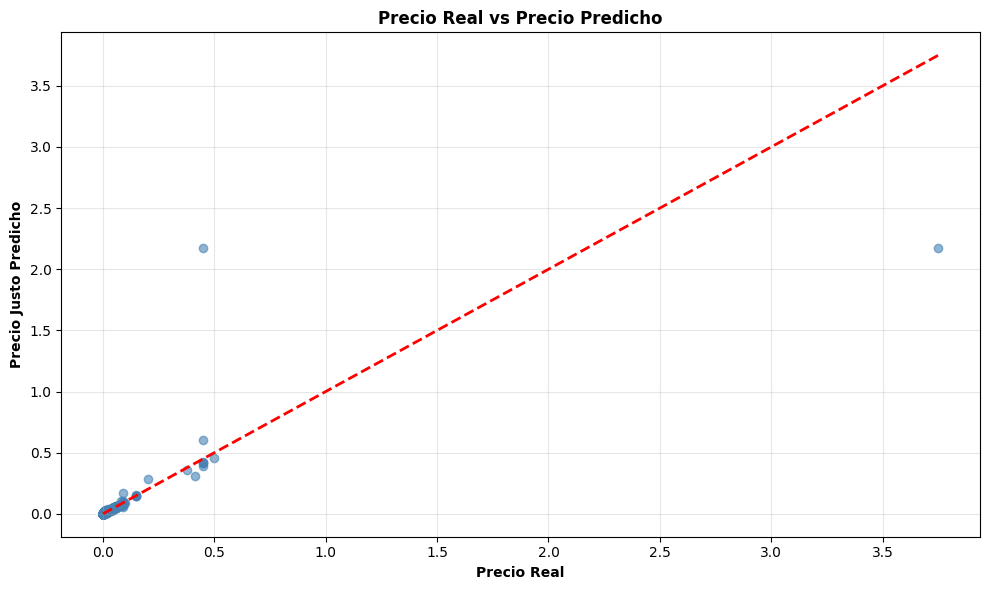

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_analisis['costo_promedio'],
    df_analisis['precio_predicho_justo'],
    alpha=0.6,
    color='steelblue'
)

# Línea perfecta
ax.plot(
    [df_analisis['costo_promedio'].min(),
     df_analisis['costo_promedio'].max()],
    
    [df_analisis['costo_promedio'].min(),
     df_analisis['costo_promedio'].max()],
    
    'r--',
    linewidth=2
)

ax.set_xlabel(
    'Precio Real',
    fontweight='bold'
)

ax.set_ylabel(
    'Precio Justo Predicho',
    fontweight='bold'
)

ax.set_title(
    'Precio Real vs Precio Predicho',
    fontweight='bold'
)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../results/plots/10_real_vs_predicho.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Explicación del Gráfico: Precio Real vs Precio Predicho

Este gráfico compara el precio real de los modelos LLM con el precio justo estimado por el modelo de Machine Learning.

Cada punto representa un modelo individual:

- Eje X → Precio real de mercado.
- Eje Y → Precio justo predicho.

La línea roja representa el escenario ideal:

\[ Precio\ Real = Precio\ Predicho \]

Mientras más cerca estén los puntos de la línea, mejor es la capacidad predictiva del modelo.



## Interpretación

| Observación | Interpretación |
|---|---|
| Puntos cerca de la línea | Precio coherente con el valor entregado |
| Puntos sobre la línea | Modelos subvaluados |
| Puntos bajo la línea | Modelos sobrevalorados |
| Alta dispersión | Mercado menos consistente |
| Concentración cerca del origen | Mayoría de modelos con precios bajos |


## ¿Por qué este gráfico es mejor que el histograma?

| Scatter Plot | Histograma |
|---|---|
| Muestra relación real vs predicho | Solo muestra frecuencia |
| Detecta sobrevaloración/subvaloración | Menos interpretativo |
| Permite identificar outliers | Más abstracto |
| Más útil para negocio | Más técnico |


## Explicación Metodológica

Este tipo de gráfico se utiliza en regresión porque permite evaluar visualmente:

- precisión del modelo,
- calidad de las predicciones,
- coherencia del mercado,
- y detección de anomalías.

Por ello, resulta más útil e interpretativo que observar únicamente errores distribuidos en un histograma.


## Conclusión

El gráfico demuestra que existe una relación consistente entre el valor técnico entregado por un modelo LLM y su precio de mercado.

Además, permite identificar modelos potencialmente sobrevalorados o subvaluados, evidenciando que el mercado sigue patrones relativamente predecibles basados en desempeño y experiencia de usuario.

# Conclusiones Finales del Proyecto

## Pregunta de Investigación

### ¿Es justo el precio de los modelos LLM?

A partir del análisis exploratorio, modelado predictivo, validación cruzada y optimización de hiperparámetros, fue posible concluir que el precio de los modelos LLM sigue patrones parcialmente predecibles basados en el valor entregado al usuario.


## Hallazgos Principales

El análisis demuestra que el precio de un modelo LLM no está determinado exclusivamente por inteligencia técnica.

Las variables con mayor influencia fueron:

| Variable | Interpretación |
|---|---|
| Velocidad de generación | Experiencia inmediata del usuario |
| Eficiencia económica | Relación entre desempeño y costo |
| Capacidad del modelo | Escalabilidad y complejidad |
| Latencia | Tiempo de respuesta percibido |
| Reputación | Confianza y posicionamiento de mercado |


## Interpretación Estratégica

Los proveedores no cobran únicamente por capacidad técnica, sino por la experiencia completa percibida por el usuario.

Esto incluye:

- rapidez,
- estabilidad,
- confianza,
- reputación,
- eficiencia operativa.

Por esta razón, modelos técnicamente similares pueden presentar diferencias importantes de precio.

---

## Resultado del Modelo Predictivo

El modelo Random Forest optimizado logró estimar precios justos utilizando variables relacionadas con valor entregado.

Esto confirma que:

- el mercado posee patrones identificables,
- el pricing no es completamente arbitrario,
- es posible detectar modelos subvalorados y sobrevalorados mediante Machine Learning.

---

## Conclusión General

El mercado de modelos LLM presenta una lógica económica coherente basada principalmente en valor percibido y experiencia de usuario.

Los modelos más costosos suelen justificar su precio mediante:

- mayor velocidad,
- menor latencia,
- mejor reputación,
- mejor experiencia operativa,
- mayor eficiencia general.

En consecuencia, sí es posible construir modelos predictivos capaces de estimar precios justos dentro del ecosistema de inteligencia artificial generativa.

---

## Reflexión Final

Este proyecto demuestra cómo técnicas de Machine Learning pueden utilizarse no solo para predicción, sino también para análisis estratégico de mercados tecnológicos emergentes.

La combinación de:
- análisis exploratorio,
- ingeniería de variables,
- regresión,
- validación cruzada,
- optimización de hiperparámetros,

permitió construir un sistema capaz de interpretar dinámicas reales de pricing dentro de la industria de modelos LLM.